# Wind drought definitions — comparison method

This notebook brings together the various wind drought definitions that have been tested and compares them
side by side, to help the group choose the preferred metric.

Three families of definitions:

| Family | Threshold | Source |
|---|---|---|
| **Threshold (absolute)** | wind < 3 m/s, < 8 m/s | ERA5 100 m, BARRA-R2 100 m |
| **Capacity factor** | CF < 0.10, < 0.20, < 0.25 | van der Wiel (ERA5) |
| **Percentile (relative)** | < p5, < p10, < p25 monthly | BARRA-R2 100 m |

For each method, we examine four aspects:

1. **Mean annual drought days**: average number of days per year in episodes lasting $\geq$ 3 days.
2. **Seasonality**: distribution across Dec–Feb / Mar–Apr / May–Jun / Jul–Aug.
3. **p99 longest drought**: duration of the longest episode (99th percentile).
4. **Domain summary**: spatial average, to compare the sensitivity of each method.

All maps are derived from the daily binary files already produced
(1 = day belonging to an episode of $\geq$ 3 days, 0 otherwise).


## 1. Imports and configuration

In [4]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

xr.set_options(keep_attrs=True)

# Domaine carte
LON_MIN, LON_MAX = 110, 155
LAT_MIN, LAT_MAX = -45, -10

MIN_CONSECUTIVE_DAYS = 3
YEAR_START, YEAR_END = 1980, 2020
N_YEARS = YEAR_END - YEAR_START + 1

OUT_DIR  = "/g/data/m35/qr1706/Conferences/Graduate Colloquium 2026/Output/"
PERC_DIR = "/scratch/nf33/GC26_energy_synoptics/barra_r2_100m_wind_speed_percentile_map/"
FIG_DIR  = os.path.join(OUT_DIR, "summary_figs")
os.makedirs(FIG_DIR, exist_ok=True)
print("xarray", xr.__version__)

xarray 2024.5.0


In [5]:
import os

files = [
    "wind_drought_binary_wind_1980_2020.nc",
    "wind_drought_binary_cf_1980_2020.nc",
    "wind_drought_binary_barra_1980_2020.nc",
    "wind_drought_binary_barra_percentile_1980_2020.nc",
]

for f in files:
    path = os.path.join(OUT_DIR, f)
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / 1e6
        print(f"OK  {f:55s} {size_mb:7.1f} MB")
    else:
        print(f"MISSING  {f}")

OK  wind_drought_binary_wind_1980_2020.nc                      23.5 MB
OK  wind_drought_binary_cf_1980_2020.nc                        50.3 MB
MISSING  wind_drought_binary_barra_1980_2020.nc
MISSING  wind_drought_binary_barra_percentile_1980_2020.nc


## 2. Method registry

Each method is declared with its file, variable and family. Missing files
are simply ignored with a warning, so you can run the notebook
even if some outputs are not yet ready. Adjust the paths and variable
names if necessary.

In [6]:
# (label, file, variable, family, dataset)
METHODS = [
    # Threshold absolute
    ("ERA5 wind < 3 m/s",  os.path.join(OUT_DIR, "wind_drought_binary_wind_1980_2020.nc"),  "wind_drought_lt3", "threshold", "ERA5"),
    ("ERA5 wind < 8 m/s",  os.path.join(OUT_DIR, "wind_drought_binary_wind_1980_2020.nc"),  "wind_drought_lt8", "threshold", "ERA5"),
    ("BARRA wind < 3 m/s", os.path.join(OUT_DIR, "wind_drought_binary_barra_1980_2020.nc"), "wind_drought_lt3", "threshold", "BARRA"),
    ("BARRA wind < 8 m/s", os.path.join(OUT_DIR, "wind_drought_binary_barra_1980_2020.nc"), "wind_drought_lt8", "threshold", "BARRA"),
    # Capacity factor
    ("CF < 0.10", os.path.join(OUT_DIR, "wind_drought_binary_cf_1980_2020.nc"), "cf_drought_010", "cf", "ERA5"),
    ("CF < 0.20", os.path.join(OUT_DIR, "wind_drought_binary_cf_1980_2020.nc"), "cf_drought_020", "cf", "ERA5"),
    ("CF < 0.25", os.path.join(OUT_DIR, "wind_drought_binary_cf_1980_2020.nc"), "cf_drought_025", "cf", "ERA5"),
    # Percentile relative
    ("BARRA < p25", os.path.join(OUT_DIR, "wind_drought_binary_barra_percentile_1980_2020.nc"), "wind_drought_p25", "percentile", "BARRA"),
    ("BARRA < p10", os.path.join(OUT_DIR, "wind_drought_binary_barra_percentile_1980_2020.nc"), "wind_drought_p10", "percentile", "BARRA"),
    ("BARRA < p05", os.path.join(OUT_DIR, "wind_drought_binary_barra_percentile_1980_2020.nc"), "wind_drought_p05", "percentile", "BARRA"),
]

# Keep only those methods for which a file exists
available = []
for label, path, var, fam, dset in METHODS:
    if os.path.exists(path):
        available.append((label, path, var, fam, dset))
    else:
        print(f"SKIP (file missing): {label}  ->  {path}")
print(f"\n{len(available)} methodes disponibles")

SKIP (file missing): BARRA wind < 3 m/s  ->  /g/data/m35/qr1706/Conferences/Graduate Colloquium 2026/Output/wind_drought_binary_barra_1980_2020.nc
SKIP (file missing): BARRA wind < 8 m/s  ->  /g/data/m35/qr1706/Conferences/Graduate Colloquium 2026/Output/wind_drought_binary_barra_1980_2020.nc
SKIP (file missing): BARRA < p25  ->  /g/data/m35/qr1706/Conferences/Graduate Colloquium 2026/Output/wind_drought_binary_barra_percentile_1980_2020.nc
SKIP (file missing): BARRA < p10  ->  /g/data/m35/qr1706/Conferences/Graduate Colloquium 2026/Output/wind_drought_binary_barra_percentile_1980_2020.nc
SKIP (file missing): BARRA < p05  ->  /g/data/m35/qr1706/Conferences/Graduate Colloquium 2026/Output/wind_drought_binary_barra_percentile_1980_2020.nc

5 methodes disponibles


## 3. Utility functions


In [9]:
def get_lat_name(o):
    for c in ("latitude", "lat", "y"):
        if c in o.coords or c in o.dims: return c
    raise KeyError("no lat")

def get_lon_name(o):
    for c in ("longitude", "lon", "x"):
        if c in o.coords or c in o.dims: return c
    raise KeyError("no lon")

def get_time_name(o):
    for c in ("time", "valid_time", "t"):
        if c in o.dims: return c
    raise KeyError("no time")

def load_binary(path, var):
    """Open a binary drought variable lazily."""
    ds = xr.open_dataset(path, chunks={"time": 500})
    return ds[var]

def mean_annual_days(da):
    """Mean number of flagged days per year."""
    t = get_time_name(da)
    total = da.sum(dim=t)
    return (total / N_YEARS).astype("float32").compute()

def seasonal_days(da):
    """Mean flagged days per year falling in each season."""
    t = get_time_name(da)
    grp = da.groupby(f"{t}.season").sum(dim=t) / N_YEARS
    return grp.astype("float32").compute()   # dims: season, lat, lon

def domain_mean(field2d):
    """Spatial mean ignoring NaN, for the bar-chart summary."""
    return float(np.nanmean(np.where(field2d > 0, field2d, np.nan)))

def plot_map(ax, lon, lat, data, title, cmap="PuRd", vmax=None, cbar_label="Days/yr"):
    ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, alpha=0.25, zorder=0)
    ax.add_feature(cfeature.OCEAN, alpha=0.15, zorder=0)
    ax.coastlines(linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.5)
    finite = data[np.isfinite(data)]
    if vmax is None:
        vmax = np.nanpercentile(finite, 99) if finite.size else 1
        vmax = max(vmax, 1)
    pm = ax.pcolormesh(lon, lat, data, cmap=cmap, vmin=0, vmax=vmax,
                       transform=ccrs.PlateCarree(), shading="auto")
    ax.set_title(title, fontsize=10)
    cb = plt.colorbar(pm, ax=ax, orientation="vertical", shrink=0.8, pad=0.03)
    cb.set_label(cbar_label)
    return pm

## 4. Calculating the ‘mean annual drought days’ maps

We calculate the average number of drought days per year for each
method once and for all, and we also store the spatial average for the final summary.

In [10]:
results = {}        # label -> dict(field, lon, lat, family, dataset)
domain_summary = {} # label -> domain-mean days/yr

for label, path, var, fam, dset in available:
    da = load_binary(path, var)
    field = mean_annual_days(da).values
    lat = da[get_lat_name(da)].values
    lon = da[get_lon_name(da)].values
    # masque les cellules toujours nulles / NaN
    field = np.where(np.isfinite(field), field, np.nan)
    results[label] = dict(field=field, lon=lon, lat=lat, family=fam, dataset=dset)
    domain_summary[label] = domain_mean(field)
    print(f"{label:22s} -> domain-mean {domain_summary[label]:5.1f} days/yr")

/home/561/qr1706/.local/lib/python3.9/site-packages/xarray/core/dataset.py:273: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 500. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(


ERA5 wind < 3 m/s      -> domain-mean   8.3 days/yr


/home/561/qr1706/.local/lib/python3.9/site-packages/xarray/core/dataset.py:273: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 500. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(


ERA5 wind < 8 m/s      -> domain-mean 204.7 days/yr


/home/561/qr1706/.local/lib/python3.9/site-packages/xarray/core/dataset.py:273: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 500. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(


CF < 0.10              -> domain-mean 100.3 days/yr


/home/561/qr1706/.local/lib/python3.9/site-packages/xarray/core/dataset.py:273: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 500. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(


CF < 0.20              -> domain-mean 180.1 days/yr


/home/561/qr1706/.local/lib/python3.9/site-packages/xarray/core/dataset.py:273: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 500. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(


CF < 0.25              -> domain-mean 207.3 days/yr


## 5. Comparison — absolute thresholds (m/s), ERA5 vs BARRA

keys found: ['ERA5 wind < 3 m/s', 'ERA5 wind < 8 m/s']
titles: ['Mean annual drought days (>=3 days) ERA5 100-wind < 3 m/s', 'Mean annual drought days (>=3 days) ERA5 100-wind < 8 m/s ']


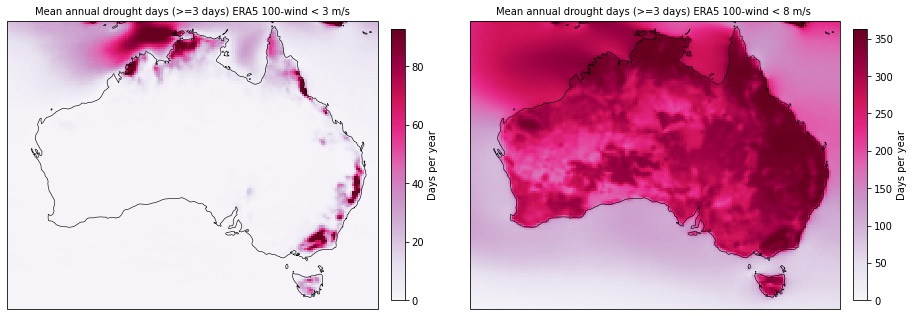

In [17]:
TITLE_MAP = {
    "ERA5 wind < 3 m/s":  "Mean annual drought days (>=3 days) ERA5 100-wind < 3 m/s",
    "ERA5 wind < 8 m/s":  "Mean annual drought days (>=3 days) ERA5 100-wind < 8 m/s ",
    "BARRA wind < 3 m/s": "BARRA-R2 10m wind < 3 m/s",
    "BARRA wind < 8 m/s": "BARRA-R2 10m wind < 8 m/s",
}

keys = ["ERA5 wind < 3 m/s", "BARRA wind < 3 m/s",
        "ERA5 wind < 8 m/s", "BARRA wind < 8 m/s"]
keys = [k for k in keys if k in results]

print("keys found:", keys)
print("titles:", [TITLE_MAP.get(k, k) for k in keys])

if keys:
    fig, axes = plt.subplots(2, 2, figsize=(13, 10),
                             subplot_kw={"projection": ccrs.PlateCarree()})
    for ax, k in zip(axes.flat, keys):
        r = results[k]
        plot_map(ax, r["lon"], r["lat"], r["field"],
                 TITLE_MAP.get(k, k),
                 cbar_label="Days per year")
    for ax in axes.flat[len(keys):]:
        ax.set_visible(False)
    fig.suptitle(
        f"Mean annual drought days (>= {MIN_CONSECUTIVE_DAYS} consecutive days)\n"
        f"Absolute wind-speed thresholds, {YEAR_START}-{YEAR_END}",
        fontsize=13, y=1.02,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    fig.savefig(os.path.join(FIG_DIR, "compare_threshold_ms.png"), dpi=150, bbox_inches="tight", pad_inches=0.3)
    plt.show()

## 6. Comparaison — capacity factor (0.10 / 0.20 / 0.25)

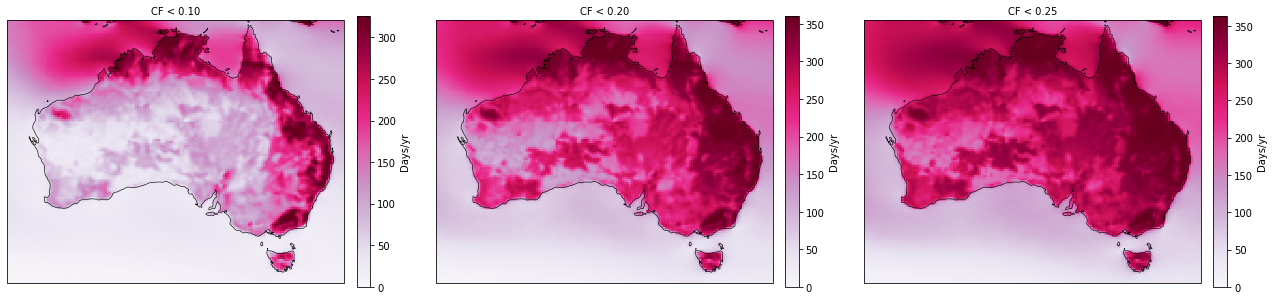

In [11]:
keys = [k for k in ["CF < 0.10", "CF < 0.20", "CF < 0.25"] if k in results]

if keys:
    fig, axes = plt.subplots(1, len(keys), figsize=(6*len(keys), 5),
                             subplot_kw={"projection": ccrs.PlateCarree()})
    axes = np.atleast_1d(axes)
    for ax, k in zip(axes, keys):
        r = results[k]
        plot_map(ax, r["lon"], r["lat"], r["field"], k)
    fig.suptitle(f"Capacity-factor thresholds — mean annual drought days, {YEAR_START}-{YEAR_END}",
                 fontsize=13, y=1.02)
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, "compare_cf.png"), dpi=150, bbox_inches="tight")
    plt.show()

## 7. Comparison — relative percentiles (p5 / p10 / p25)

In [7]:
keys = [k for k in ["BARRA < p05", "BARRA < p10", "BARRA < p25"] if k in results]

if keys:
    fig, axes = plt.subplots(1, len(keys), figsize=(6*len(keys), 5),
                             subplot_kw={"projection": ccrs.PlateCarree()})
    axes = np.atleast_1d(axes)
    for ax, k in zip(axes, keys):
        r = results[k]
        plot_map(ax, r["lon"], r["lat"], r["field"], k, cmap="PuRd")
    fig.suptitle(f"Monthly-percentile thresholds — mean annual drought days, {YEAR_START}-{YEAR_END}",
                 fontsize=13, y=1.02)
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, "compare_percentile.png"), dpi=150, bbox_inches="tight")
    plt.show()

## 8. Seasonality

We select a representative method for each family and plot the seasonal distribution
of drought days. Change `season_methods` to compare other options.

/home/561/qr1706/.local/lib/python3.9/site-packages/xarray/core/dataset.py:273: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 500. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(


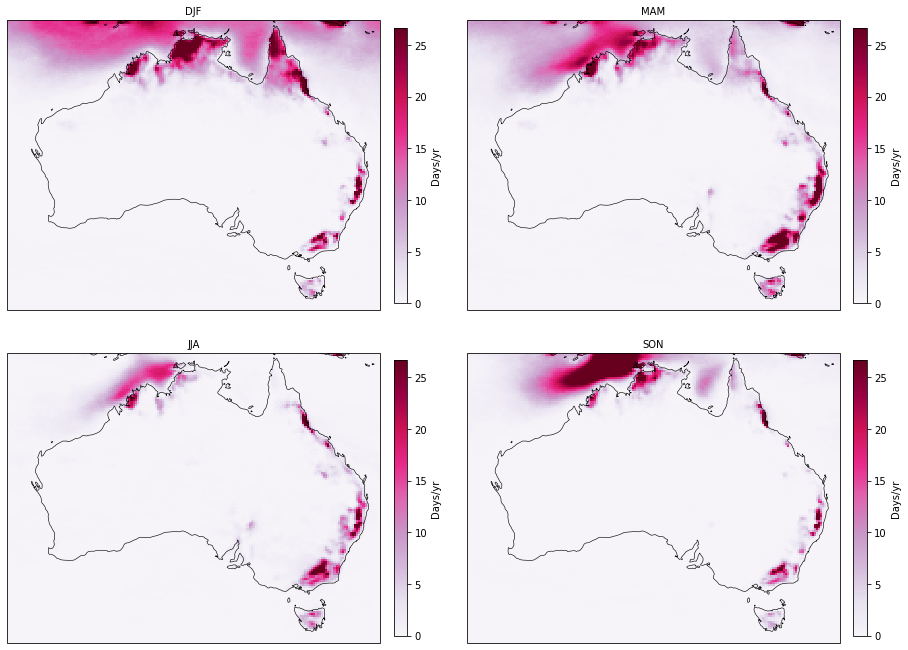

/home/561/qr1706/.local/lib/python3.9/site-packages/xarray/core/dataset.py:273: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 500. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(


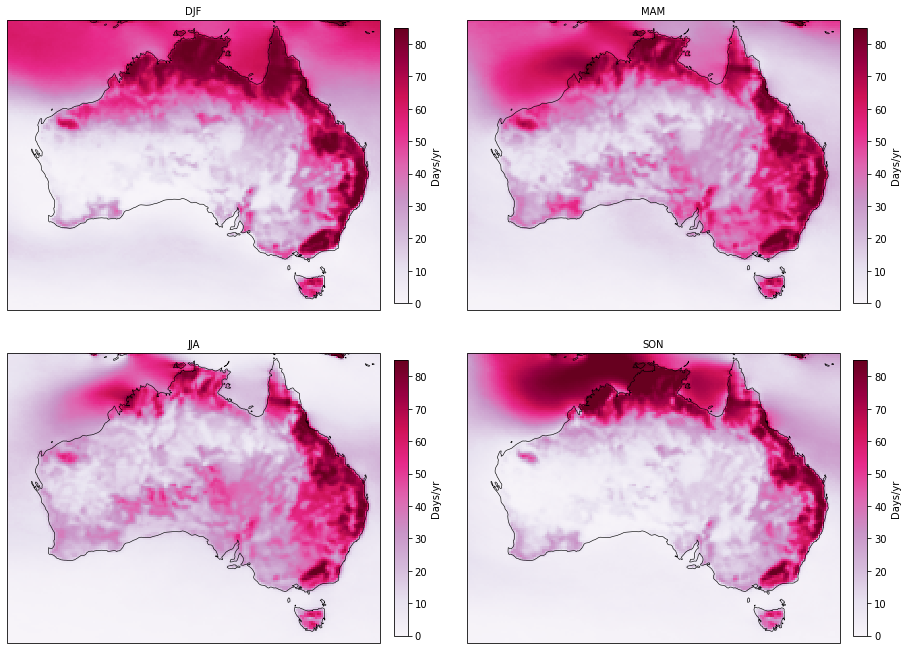

In [22]:
season_methods = [m for m in ["ERA5 wind < 3 m/s", "CF < 0.10", "ERA5 < p10"] if m in results]

for label in season_methods:
    path, var = None, None
    for l, p, v, fam, dset in available:
        if l == label:
            path, var = p, v
            break
    da = load_binary(path, var)
    seas = seasonal_days(da)
    lat = da[get_lat_name(da)].values
    lon = da[get_lon_name(da)].values

    order = ["DJF", "MAM", "JJA", "SON"]
    present = [s for s in order if s in seas["season"].values]
    vmax = np.nanpercentile(seas.values[np.isfinite(seas.values)], 99)

    fig, axes = plt.subplots(2, 2, figsize=(13, 10),
                             subplot_kw={"projection": ccrs.PlateCarree()})
    for ax, s in zip(axes.flat, present):
        field = seas.sel(season=s).values
        plot_map(ax, lon, lat, field, s, vmax=vmax)
    fig.suptitle(f"{label} — seasonal drought days per year, {YEAR_START}-{YEAR_END}",
                 fontsize=13, y=0.99)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    fname = os.path.join(FIG_DIR, f"seasonal_{label.replace(' ', '_').replace('<','lt').replace('.','').replace('/','')}.png")
    fig.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()

/home/561/qr1706/.local/lib/python3.9/site-packages/xarray/core/dataset.py:273: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 500. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(


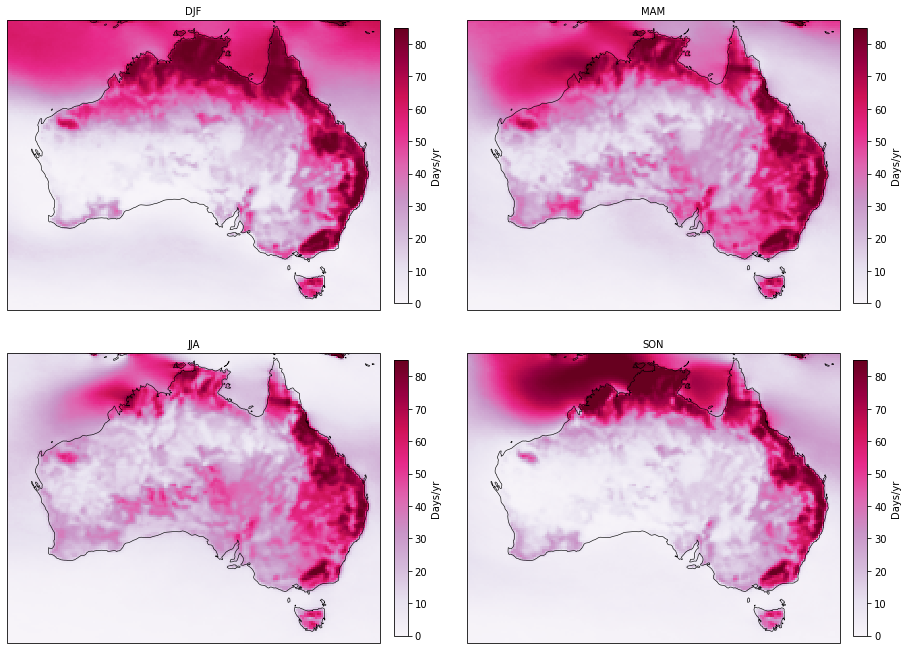

/home/561/qr1706/.local/lib/python3.9/site-packages/xarray/core/dataset.py:273: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 500. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(


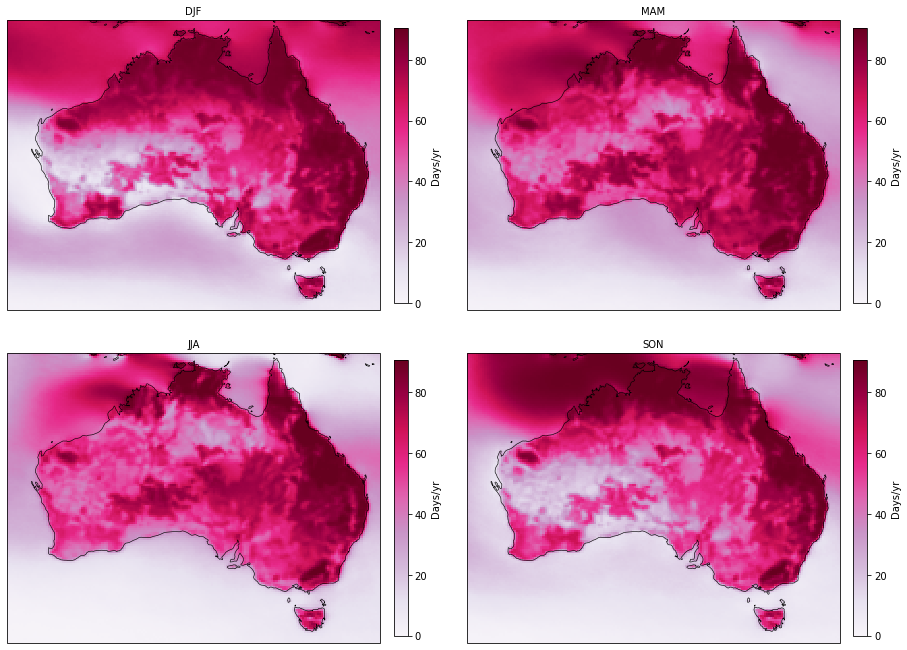

/home/561/qr1706/.local/lib/python3.9/site-packages/xarray/core/dataset.py:273: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 500. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(


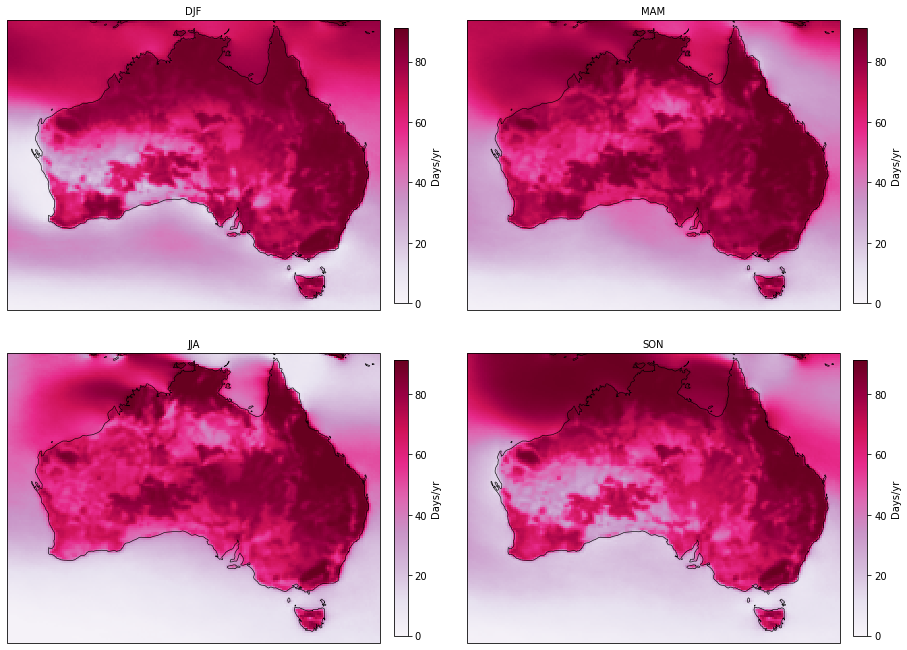

In [19]:
season_methods = [
    m for m in [
        "BARRA wind < 8 m/s",
        "CF < 0.10",
        "CF < 0.20",
        "CF < 0.25",
        "BARRA < p10",
    ]
    if m in results
]

for label in season_methods:
    path, var = None, None
    for l, p, v, fam, dset in available:
        if l == label:
            path, var = p, v
            break
    da = load_binary(path, var)
    seas = seasonal_days(da)
    lat = da[get_lat_name(da)].values
    lon = da[get_lon_name(da)].values

    order = ["DJF", "MAM", "JJA", "SON"]
    present = [s for s in order if s in seas["season"].values]
    vmax = np.nanpercentile(seas.values[np.isfinite(seas.values)], 99)

    fig, axes = plt.subplots(2, 2, figsize=(13, 10),
                             subplot_kw={"projection": ccrs.PlateCarree()})
    for ax, s in zip(axes.flat, present):
        field = seas.sel(season=s).values
        plot_map(ax, lon, lat, field, s, vmax=vmax)
    fig.suptitle(f"{label} — seasonal drought days per year, {YEAR_START}-{YEAR_END}",
                 fontsize=13, y=0.97)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    fname = os.path.join(FIG_DIR, f"seasonal_{label.replace(' ', '_').replace('<','lt').replace('.','')}.png")
    fig.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()

## 9. p99 longest drought duration

From the binary file, consecutive 1s form an episode (episodes are
separated by 0s). We collect the duration of all episodes for each grid point and
take the 99th percentile.

The lat/lon loop is slow on the BARRA grid. For a quick overview, set
`COARSEN` > 1 (e.g. 4) to subsample the grid, or run this section as a
separate PBS job.

/home/561/qr1706/.local/lib/python3.9/site-packages/xarray/core/dataset.py:273: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 500. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/home/561/qr1706/.local/lib/python3.9/site-packages/xarray/core/dataset.py:273: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 500. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(


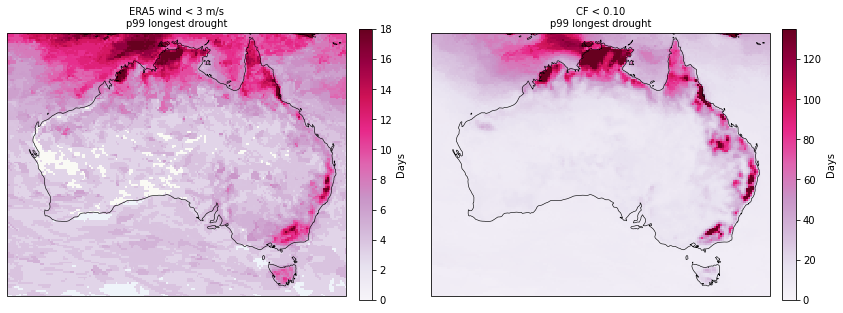

In [23]:
COARSEN = 1

def episode_p99(binary_da, percentile=99, coarsen=1):
    t = get_time_name(binary_da)
    if coarsen > 1:
        binary_da = binary_da.isel(
            {get_lat_name(binary_da): slice(None, None, coarsen),
             get_lon_name(binary_da): slice(None, None, coarsen)}
        )
    arr = binary_da.transpose(t, get_lat_name(binary_da), get_lon_name(binary_da)).values
    arr = (arr > 0)
    nt, nlat, nlon = arr.shape
    out = np.full((nlat, nlon), np.nan, dtype="float32")
    for ilat in range(nlat):
        for ilon in range(nlon):
            col = arr[:, ilat, ilon]
            durs, run = [], 0
            for v in col:
                if v:
                    run += 1
                else:
                    if run > 0: durs.append(run)
                    run = 0
            if run > 0: durs.append(run)
            if durs:
                out[ilat, ilon] = np.percentile(durs, percentile)
    lat = binary_da[get_lat_name(binary_da)].values
    lon = binary_da[get_lon_name(binary_da)].values
    return out, lon, lat

p99_methods = [m for m in ["ERA5 wind < 3 m/s", "CF < 0.10", "BARRA < p10"] if m in results]

fig, axes = plt.subplots(1, len(p99_methods), figsize=(6*len(p99_methods), 5),
                         subplot_kw={"projection": ccrs.PlateCarree()})
axes = np.atleast_1d(axes)
for ax, label in zip(axes, p99_methods):
    for l, p, v, fam, dset in available:
        if l == label:
            da = load_binary(p, v)
            break
    field, lon, lat = episode_p99(da, 99, COARSEN)
    plot_map(ax, lon, lat, field, f"{label}\np99 longest drought", cmap="PuRd", cbar_label="Days")
fig.suptitle(f"99th-percentile longest drought duration (coarsen={COARSEN}), {YEAR_START}-{YEAR_END}",
             fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "compare_p99_length.png"), dpi=150, bbox_inches="tight")
plt.show()

## 10. Summary for decision-making

Spatially averaged number of drought days per year, for all methods.
This shows at a glance just how much the result depends on the choice of definition and
the data source.

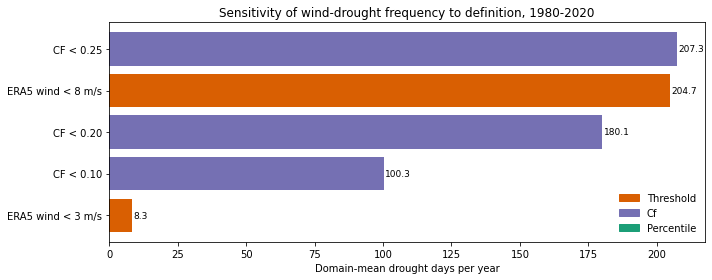

In [10]:
labels = list(domain_summary.keys())
values = [domain_summary[l] for l in labels]

# couleur par famille
fam_color = {"threshold": "#d95f02", "cf": "#7570b3", "percentile": "#1b9e77"}
fam_of = {l: r["family"] for l, r in results.items()}
colors = [fam_color.get(fam_of[l], "#999999") for l in labels]

order = np.argsort(values)
labels = [labels[i] for i in order]
values = [values[i] for i in order]
colors = [colors[i] for i in order]

fig, ax = plt.subplots(figsize=(10, 0.5*len(labels)+1.5))
ax.barh(labels, values, color=colors)
ax.set_xlabel("Domain-mean drought days per year")
ax.set_title(f"Sensitivity of wind-drought frequency to definition, {YEAR_START}-{YEAR_END}")
for i, v in enumerate(values):
    ax.text(v + 0.5, i, f"{v:.1f}", va="center", fontsize=9)

handles = [plt.Rectangle((0,0),1,1,color=c) for c in fam_color.values()]
ax.legend(handles, [f.capitalize() for f in fam_color], loc="lower right", frameon=False)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "decision_summary_bar.png"), dpi=150, bbox_inches="tight")
plt.show()

In [33]:
# Bounding boxes approximatives par Etat/Territoire (lon_min, lon_max, lat_min, lat_max)
STATE_BBOX = {
    "WA":  (112.0, 129.0, -35.5, -13.5),
    "NT":  (129.0, 138.0, -26.0, -10.5),
    "SA":  (129.0, 141.0, -38.5, -26.0),
    "QLD": (138.0, 154.0, -29.0, -10.0),
    "NSW": (141.0, 154.0, -37.5, -28.0),
    "VIC": (141.0, 150.0, -39.5, -33.8),
    "TAS": (144.5, 148.4, -43.6, -40.5),
}

def state_mean(field, lon, lat, bbox):
    """Mean over a lon/lat bounding box, ignoring zeros/NaN."""
    lon_min, lon_max, lat_min, lat_max = bbox
    lon2d, lat2d = np.meshgrid(lon, lat)
    inside = (
        (lon2d >= lon_min) & (lon2d <= lon_max) &
        (lat2d >= lat_min) & (lat2d <= lat_max)
    )
    vals = np.where(inside & np.isfinite(field) & (field > 0), field, np.nan)
    return np.nanmean(vals)

In [34]:
# Construit un tableau : etats en lignes, methodes en colonnes
state_names = list(STATE_BBOX.keys())
method_labels = list(results.keys())

state_matrix = np.full((len(state_names), len(method_labels)), np.nan)

for j, label in enumerate(method_labels):
    r = results[label]
    for i, st in enumerate(state_names):
        state_matrix[i, j] = state_mean(r["field"], r["lon"], r["lat"], STATE_BBOX[st])

print("Computed state x method matrix:", state_matrix.shape)

Computed state x method matrix: (7, 5)


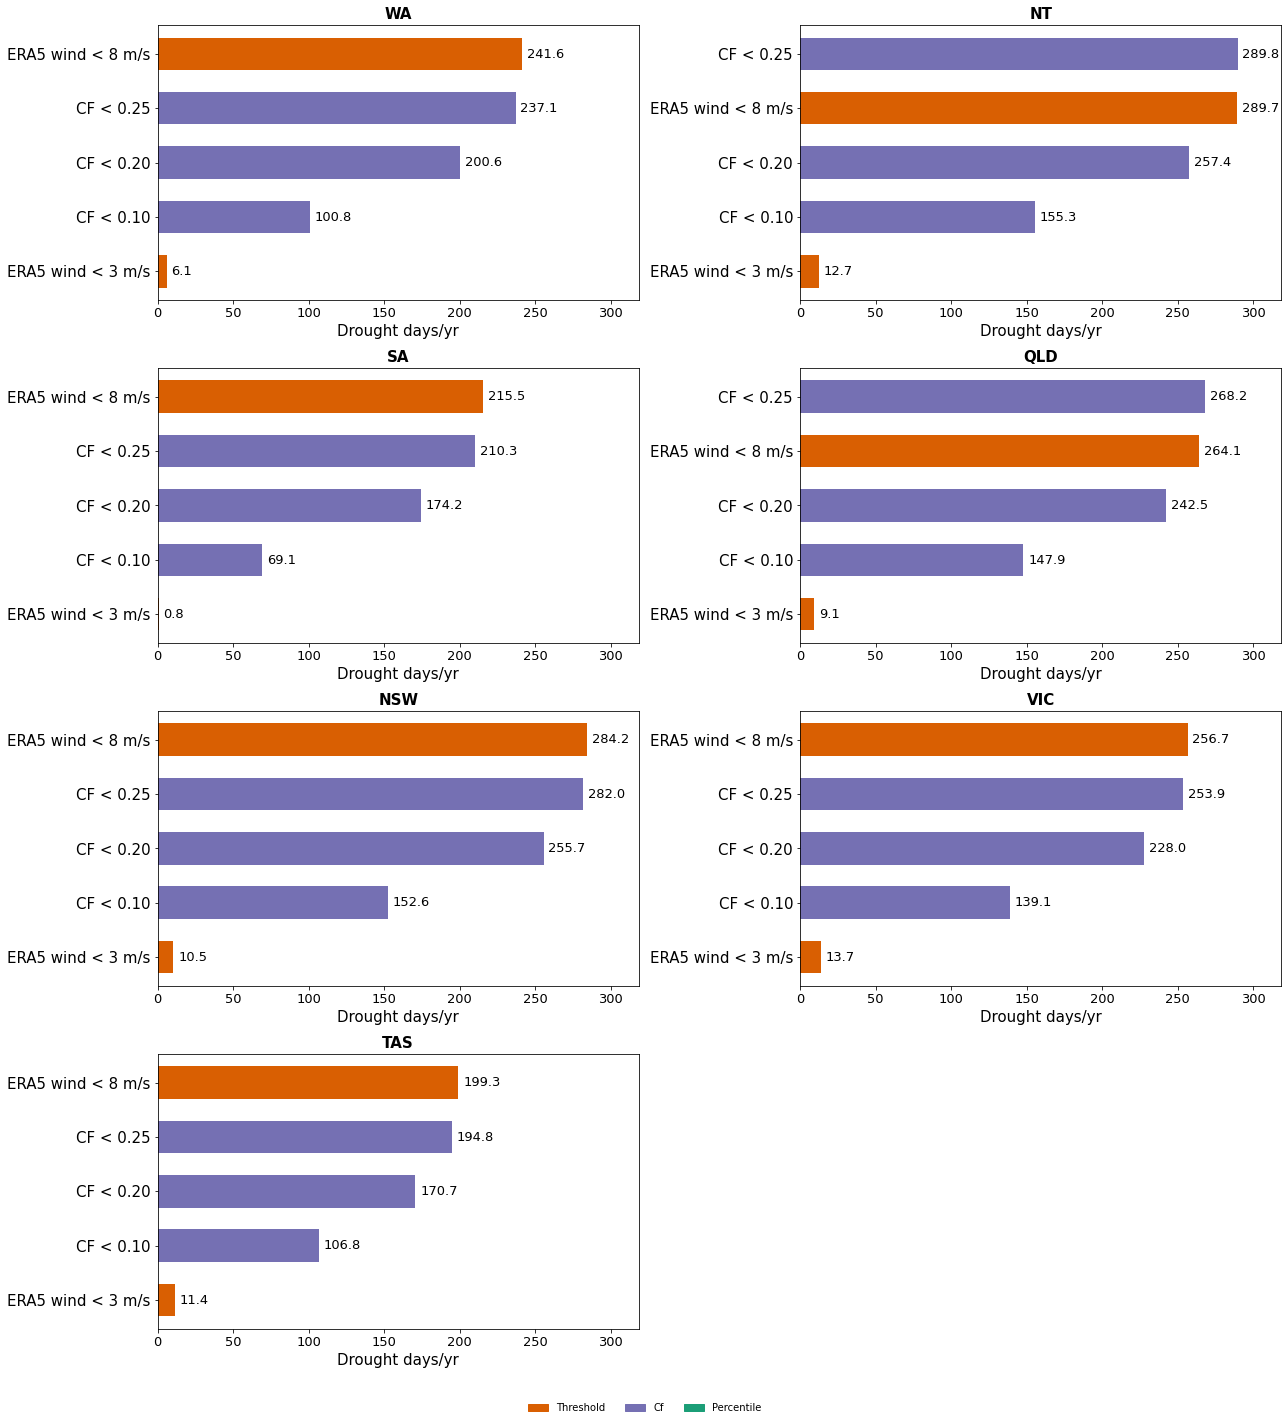

In [35]:
fam_color = {"threshold": "#d95f02", "cf": "#7570b3", "percentile": "#1b9e77"}
fam_of = {l: r["family"] for l, r in results.items()}

xmax = np.nanmax(state_matrix) * 1.1
n_states = len(state_names)
ncols = 2
nrows = int(np.ceil(n_states / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes = axes.flat

for i, st in enumerate(state_names):
    ax = axes[i]
    vals = state_matrix[i, :]
    colors = [fam_color.get(fam_of[l], "#999999") for l in method_labels]

    order = np.argsort(np.nan_to_num(vals))
    lbls = [method_labels[k] for k in order]
    vv   = [vals[k] for k in order]
    cc   = [colors[k] for k in order]

    ax.barh(lbls, vv, color=cc, height=0.6)
    ax.set_xlim(0, xmax)
    ax.set_title(st, fontsize=15, fontweight="bold")
    ax.set_xlabel("Drought days/yr", fontsize=15)
    ax.tick_params(axis="y", labelsize=15)
    ax.tick_params(axis="x", labelsize=13)   # chiffres axe x plus grands
    for y, v in enumerate(vv):
        if np.isfinite(v):
            ax.text(v + xmax * 0.01, y, f"{v:.1f}", va="center", fontsize=13)  # annotations plus grandes

for ax in axes[n_states:]:
    ax.set_visible(False)

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in fam_color.values()]
fig.legend(handles, [f.capitalize() for f in fam_color],
           loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.01))
fig.suptitle(f"Wind-drought frequency by state and definition, {YEAR_START}-{YEAR_END}",
             fontsize=15, y=1.01)
fig.tight_layout(rect=[0, 0.02, 1, 0.98])
fig.savefig(os.path.join(FIG_DIR, "decision_summary_by_state.png"), dpi=150, bbox_inches="tight")
plt.show()

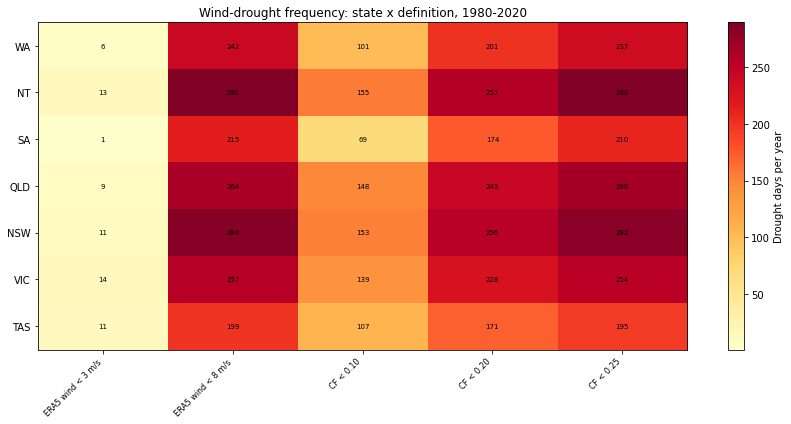

In [36]:
fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(state_matrix, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(len(method_labels)))
ax.set_xticklabels(method_labels, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(state_names)))
ax.set_yticklabels(state_names)
for i in range(len(state_names)):
    for j in range(len(method_labels)):
        v = state_matrix[i, j]
        if np.isfinite(v):
            ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7)
cb = plt.colorbar(im, ax=ax)
cb.set_label("Drought days per year")
ax.set_title(f"Wind-drought frequency: state x definition, {YEAR_START}-{YEAR_END}")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "decision_summary_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()

In [37]:
def state_daily_fraction(da, bbox):
    """
    Fraction of grid cells inside a bbox that are in drought each day.
    Returns a 1D time series.
    """
    lon_name, lat_name, t = get_lon_name(da), get_lat_name(da), get_time_name(da)
    lon = da[lon_name].values
    lat = da[lat_name].values
    lon2d, lat2d = np.meshgrid(lon, lat)

    lon_min, lon_max, lat_min, lat_max = bbox
    inside = (
        (lon2d >= lon_min) & (lon2d <= lon_max) &
        (lat2d >= lat_min) & (lat2d <= lat_max)
    )
    # Masque applique sur (lat, lon), moyenne spatiale par jour
    masked = da.where(xr.DataArray(inside, dims=(lat_name, lon_name)))
    return masked.mean(dim=(lat_name, lon_name)).compute()

/home/561/qr1706/.local/lib/python3.9/site-packages/xarray/core/dataset.py:273: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 500. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(


  WA: 14976 days
  NT: 14976 days
  SA: 14976 days
  QLD: 14976 days
  NSW: 14976 days
  VIC: 14976 days
  TAS: 14976 days


FileNotFoundError: [Errno 2] No such file or directory: '/g/data/m35/qr1706/Conferences/Graduate Colloquium 2026/Output/summary_figs/correlation_ERA5_wind_lt_3_m/s.png'

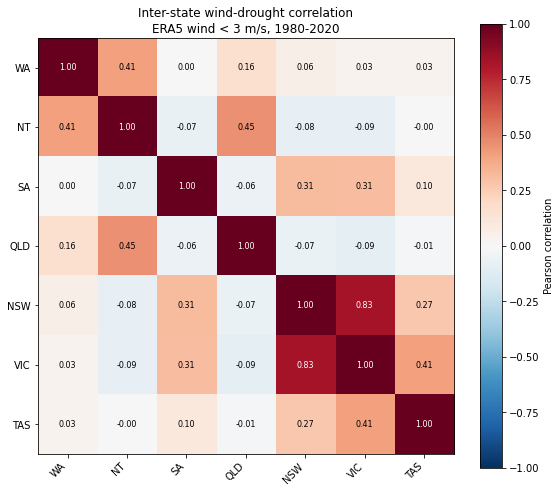

In [38]:
import pandas as pd
corr_methods_to_run = ["ERA5 wind < 3 m/s", "ERA5 wind < 8 m/s", "CF < 0.10", "CF < 0.20", "CF < 0.25"]

for CORR_METHOD in corr_methods_to_run:
    path, var = None, None
    for l, p, v, fam, dset in available:
        if l == CORR_METHOD:
            path, var = p, v
            break

    if path is None:
        print(f"SKIP: {CORR_METHOD} not available")
        continue

    da_corr = load_binary(path, var)

    state_series = {}
    for st, bbox in STATE_BBOX.items():
        state_series[st] = state_daily_fraction(da_corr, bbox).values
        print(f"  {st}: {len(state_series[st])} days")

    df = pd.DataFrame(state_series)
    corr = df.corr(method="pearson")

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(corr.index)))
    ax.set_yticklabels(corr.index)
    for i in range(len(corr.index)):
        for j in range(len(corr.columns)):
            ax.text(j, i, f"{corr.values[i, j]:.2f}",
                    ha="center", va="center", fontsize=8,
                    color="white" if abs(corr.values[i, j]) > 0.6 else "black")
    cb = plt.colorbar(im, ax=ax)
    cb.set_label("Pearson correlation")
    ax.set_title(f"Inter-state wind-drought correlation\n{CORR_METHOD}, {YEAR_START}-{YEAR_END}")
    fig.tight_layout()
    fname = os.path.join(FIG_DIR, f"correlation_{CORR_METHOD.replace(' ', '_').replace('<','lt').replace('.','')}.png")
    fig.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}\n")

In [ ]:
print("CORR_METHOD:", CORR_METHOD)
print("Available labels:", [l for l, *_ in available])
print("path =", path, "| var =", var)

In [ ]:
import pandas as pd

df = pd.DataFrame(state_series)
corr = df.corr(method="pearson")
print(corr.round(2))

In [ ]:
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)

# Annoter chaque case
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}",
                ha="center", va="center", fontsize=8,
                color="white" if abs(corr.values[i, j]) > 0.6 else "black")

cb = plt.colorbar(im, ax=ax)
cb.set_label("Pearson correlation")
ax.set_title(f"Inter-state wind-drought correlation\n{CORR_METHOD}, {YEAR_START}-{YEAR_END}")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "state_correlation_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()

## 11. How to choose — a quick guide

A few points to guide the group discussion.

**Absolute threshold (m/s)**
Simple, transparent, directly based on physical principles (cut-in at 3 m/s, low output below 8 m/s).
But does not take regional variability into account: a fixed threshold mainly identifies
areas that are structurally low-wind (the centre of the continent) rather than local anomalies.
Good for communication, less good for comparing regions.

**Capacity factor**
Closest to the actual grid impact, as it incorporates the power curve. CF < 0.25
is the standard choice in the Australian literature. Limitation: depends on the
van der Wiel reference turbine and is only available here for ERA5.

**Relative percentile**
Puts every point on an equal footing (by definition, every region has the same number
of days below its own p10). Ideal for studying circulation anomalies and the link
with weather regimes, because it isolates the synoptic signal from the climatological background.
Less meaningful for an energy audience, as ‘below the p10’ says nothing about
absolute production.

**Standard recommendation for a conference**
- Communication / grid impact: **CF < 0.25**.
- Synoptic analysis and weather regimes: **percentile (p10)**.
- The absolute threshold in m/s is mainly used to verify robustness between ERA5 and BARRA.

The figure in Section 10 helps to show that the qualitative conclusion (where and when
droughts are frequent) is robust to the choice of method, even if the absolute figures
vary significantly.
